# Validation 10 — Complexity & Reliability (Cells 28–29)
Verifies ops formula (2×9×sections), CV column, 15 rows, timing columns.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time, warnings
from pathlib import Path
from scipy.signal import butter,cheby1,cheby2,ellip,bessel,sosfiltfilt,sosfreqz,welch
from scipy.signal import spectrogram as sp_spectrogram
from scipy.io import wavfile
from itertools import product
warnings.filterwarnings('ignore')

BASE_DIR    = Path(r"D:\\1 placement\\IAESTE INTERNSHIP CZECH\\iaeste26-blasting-sound-main\\iaeste26-blasting-sound-main")
DATA_DIR    = BASE_DIR / "data"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

SENSOR_PRIORITY   = ['AccAxial4507','AccRadial4507','Mic147EB','Mic46BE']
ENERGY_WINDOW_S   = 0.05;  NOISE_DURATION_S = 0.5;  ONSET_THRESHOLD = 10.0;  ONSET_OFFSET_S = 7.0
WINDOW_DURATION_S = 5.0;   WINDOW_STEP_S    = 1.0
LOWER_LIMITS = [176,225,283,353,440,565,707,880,1130,1414,1760,10,10,500,1000]
UPPER_LIMITS = [225,283,353,440,565,707,880,1130,1414,1760,2220,1000,2000,1500,2000]
N_BANDS      = len(LOWER_LIMITS)
BAND_LABELS  = [f"{lo}–{hi} Hz" for lo,hi in zip(LOWER_LIMITS,UPPER_LIMITS)]
FILTER_TYPES  = ['Butterworth','Chebyshev I','Chebyshev II','Elliptical','Bessel']
FILTER_ORDERS = [3,5,7]
CHEBY1_RIPPLE_DB=0.5; CHEBY2_ATTEN_DB=40.0; ELLIP_RIPPLE_DB=0.5; ELLIP_ATTEN_DB=40.0

P=[0]; F=[0]
def check(label, ok, note=""):
    s="[PASS]" if ok else "[FAIL]"
    if ok: P[0]+=1
    else:  F[0]+=1
    print(f"  {s}  {label}" + (f"  → {note}" if note else ""))
def info(label, val): print(f"  [INFO]  {label}: {val}")
def summary():
    t=P[0]+F[0]
    print(f"\n{'='*50}")
    print(f"  PASS: {P[0]}/{t}  |  FAIL: {F[0]}/{t}")
    print(f"  Score: {P[0]/t*100:.0f}%" if t else "  No checks run")
    print('='*50)
print("Config loaded.")


Config loaded.


In [2]:
def load_wav(path):
    fs,data=wavfile.read(path)
    if data.ndim>1: data=data[:,0]
    if   data.dtype==np.int16:  sig=data.astype(np.float64)/32768.0
    elif data.dtype==np.int32:  sig=data.astype(np.float64)/2147483648.0
    else:                       sig=data.astype(np.float64)
    return fs,sig,len(sig)/fs

def detect_onset(signal,fs):
    hop=int(ENERGY_WINDOW_S*fs); n=len(signal)//hop
    rms=np.array([np.sqrt(np.mean(signal[i*hop:(i+1)*hop]**2)) for i in range(n)])
    nf=np.mean(rms[:max(1,int(NOISE_DURATION_S/ENERGY_WINDOW_S))])
    ab=np.where(rms>ONSET_THRESHOLD*nf)[0]
    of=int(ab[0]) if len(ab) else int(np.argmax(rms))
    return of*hop, of*ENERGY_WINDOW_S, np.arange(n)*ENERGY_WINDOW_S, rms, nf

def make_windows(signal,fs):
    wl=int(WINDOW_DURATION_S*fs); sl=int(WINDOW_STEP_S*fs)
    n=max(0,(len(signal)-wl)//sl+1)
    return [signal[i*sl:i*sl+wl] for i in range(n)], np.arange(n)*WINDOW_STEP_S

def design_filter(ftype,order,lo,hi,fs):
    nyq=fs/2.; Wn=[lo/nyq,hi/nyq]
    if ftype=='Butterworth':  return butter(order,Wn,btype='bandpass',output='sos')
    if ftype=='Chebyshev I':  return cheby1(order,CHEBY1_RIPPLE_DB,Wn,btype='bandpass',output='sos')
    if ftype=='Chebyshev II': return cheby2(order,CHEBY2_ATTEN_DB,Wn,btype='bandpass',output='sos')
    if ftype=='Elliptical':   return ellip(order,ELLIP_RIPPLE_DB,ELLIP_ATTEN_DB,Wn,btype='bandpass',output='sos')
    if ftype=='Bessel':       return bessel(order,Wn,btype='bandpass',output='sos',norm='phase')

all_wavs = sorted(set(DATA_DIR.rglob("*.wav"))|set(DATA_DIR.rglob("*.WAV")))
def skey(p):
    s=Path(p).stem.split('_')[-1]
    return SENSOR_PRIORITY.index(s) if s in SENSOR_PRIORITY else 99
all_wavs = sorted(all_wavs,key=skey)
EXAMPLE_WAV = all_wavs[0] if all_wavs else None
print(f"WAV files found: {len(all_wavs)}")
if EXAMPLE_WAV: print(f"Using: {EXAMPLE_WAV.name}")


WAV files found: 1568
Using: G80_8_3_0_AccAxial4507.wav


  [PASS]  Complexity table has 15 rows  → 15 rows
  [PASS]  All 5 filter types present
  [PASS]  RMS CV column present
  [PASS]  RMS Calc (μs) column present
  [PASS]  CF Calc (μs) column present
  [PASS]  Mean Time/Window > 0
  [PASS]  Ops increase with order (all types)
  [PASS]  Ops formula [Butterworth N=3]: 2×9×sections  → got 54, expected 54
  [PASS]  Ops formula [Chebyshev I N=3]: 2×9×sections  → got 54, expected 54
  [PASS]  Ops formula [Chebyshev II N=3]: 2×9×sections  → got 54, expected 54
  [PASS]  Ops formula [Elliptical N=3]: 2×9×sections  → got 54, expected 54
  [PASS]  Ops formula [Bessel N=3]: 2×9×sections  → got 54, expected 54
  [PASS]  Ops formula [Butterworth N=5]: 2×9×sections  → got 90, expected 90
  [PASS]  Ops formula [Chebyshev I N=5]: 2×9×sections  → got 90, expected 90
  [PASS]  Ops formula [Chebyshev II N=5]: 2×9×sections  → got 90, expected 90
  [PASS]  Ops formula [Elliptical N=5]: 2×9×sections  → got 90, expected 90
  [PASS]  Ops formula [Bessel N=5]: 2×9

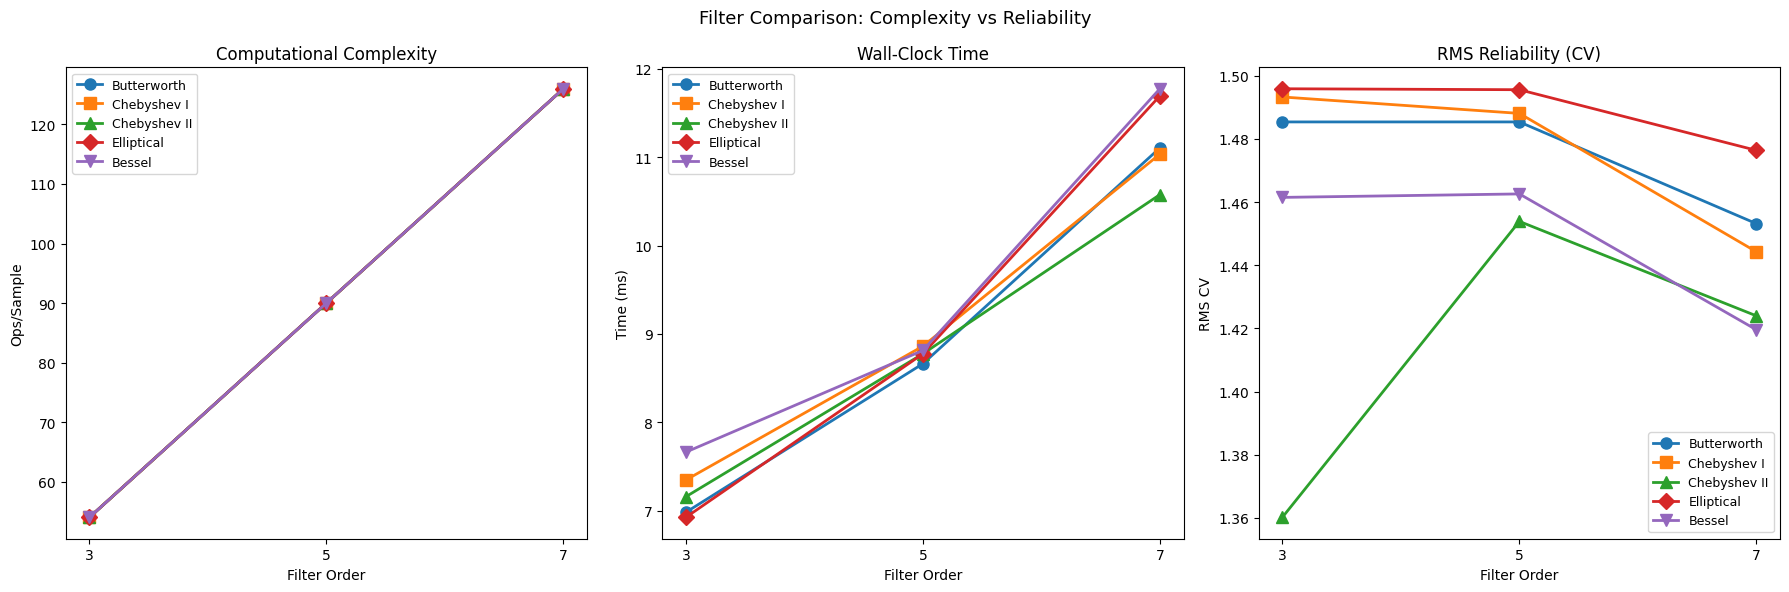


  PASS: 22/22  |  FAIL: 0/22
  Score: 100%


In [3]:
csv_path=RESULTS_DIR/"blasting_all_results.csv"
if not csv_path.exists(): print("[SKIP] Run validation_08 first"); raise SystemExit
df=pd.read_csv(csv_path)
fs,_,_=load_wav(EXAMPLE_WAV) if EXAMPLE_WAV else (48000,None,None)

filter_cache={}
for ftype,order,(lo,hi) in product(FILTER_TYPES,FILTER_ORDERS,zip(LOWER_LIMITS,UPPER_LIMITS)):
    k=(ftype,order,lo,hi)
    try: filter_cache[k]=design_filter(ftype,order,lo,hi,fs)
    except: filter_cache[k]=None

timing={}
rows=[]
for ftype,order in product(FILTER_TYPES,FILTER_ORDERS):
    sos=next((filter_cache.get((ftype,order,lo,hi)) for lo,hi in zip(LOWER_LIMITS,UPPER_LIMITS) if filter_cache.get((ftype,order,lo,hi)) is not None),None)
    if sos is None: continue
    n_sec=len(sos); ops_ff=2*9*n_sec
    avg_ms=df[(df.filter_type==ftype)&(df.order==order)]['filter_time_ms'].mean() if 'filter_time_ms' in df.columns else np.nan
    sub=df[(df.filter_type==ftype)&(df.order==order)]
    cv=(sub['rms'].std()/sub['rms'].mean()) if sub['rms'].mean()>0 else np.nan
    mean_rms_us=sub['rms_time_us'].mean() if 'rms_time_us' in sub.columns else np.nan
    mean_cf_us =sub['cf_time_us'].mean()  if 'cf_time_us'  in sub.columns else np.nan
    rows.append({'Filter Type':ftype,'Order':order,'SOS Sections':n_sec,
                 'Ops/Sample (filtfilt)':ops_ff,'Mean Time/Window (ms)':round(avg_ms,3),
                 'RMS Calc (μs)':round(mean_rms_us,2),'CF Calc (μs)':round(mean_cf_us,2),'RMS CV':round(cv,4)})

df_cx=pd.DataFrame(rows).sort_values(['Order','Ops/Sample (filtfilt)']).reset_index(drop=True)

check("Complexity table has 15 rows",     len(df_cx)==15,                f"{len(df_cx)} rows")
check("All 5 filter types present",       set(df_cx['Filter Type'].unique())==set(FILTER_TYPES))
check("RMS CV column present",            'RMS CV' in df_cx.columns)
check("RMS Calc (μs) column present",     'RMS Calc (μs)' in df_cx.columns)
check("CF Calc (μs) column present",      'CF Calc (μs)'  in df_cx.columns)
check("Mean Time/Window > 0",             (df_cx['Mean Time/Window (ms)']>0).all())
check("Ops increase with order (all types)",
      all(df_cx[df_cx['Filter Type']==ft].sort_values('Order')['Ops/Sample (filtfilt)'].is_monotonic_increasing for ft in FILTER_TYPES))

for _,row in df_cx.iterrows():
    exp=2*9*row['SOS Sections']
    check(f"Ops formula [{row['Filter Type']} N={row['Order']}]: 2×9×sections",
          row['Ops/Sample (filtfilt)']==exp, f"got {row['Ops/Sample (filtfilt)']}, expected {exp}")

print(); print(df_cx.to_string(index=False))

fig,axes=plt.subplots(1,3,figsize=(18,6))
m={'Butterworth':'o','Chebyshev I':'s','Chebyshev II':'^','Elliptical':'D','Bessel':'v'}
c={'Butterworth':'#1f77b4','Chebyshev I':'#ff7f0e','Chebyshev II':'#2ca02c','Elliptical':'#d62728','Bessel':'#9467bd'}
for ft in FILTER_TYPES:
    sub=df_cx[df_cx['Filter Type']==ft].sort_values('Order')
    kw=dict(marker=m[ft],color=c[ft],lw=2,markersize=8,label=ft)
    axes[0].plot(sub['Order'],sub['Ops/Sample (filtfilt)'],**kw)
    axes[1].plot(sub['Order'],sub['Mean Time/Window (ms)'],**kw)
    axes[2].plot(sub['Order'],sub['RMS CV'],**kw)
for ax,yl,ti in zip(axes,['Ops/Sample','Time (ms)','RMS CV'],
                    ['Computational Complexity','Wall-Clock Time','RMS Reliability (CV)']):
    ax.set_xlabel('Filter Order'); ax.set_ylabel(yl); ax.set_title(ti)
    ax.set_xticks(FILTER_ORDERS); ax.legend(fontsize=9)
fig.suptitle('Filter Comparison: Complexity vs Reliability',fontsize=13)
plt.tight_layout(); plt.show(); plt.close('all')
summary()
